# Cálculo del Valor en Riesgo y Valor en Riesgo Condicional

En este notebook estudiaremos dos medidas fundamentales de riesgo financiero:

- Valor en Riesgo, conocido como VaR.
- Valor en Riesgo Condicional, conocido como CVaR o Expected Shortfall.

El objetivo es construir una rutina completa para estimar estas medidas usando distintos métodos:

1. Método histórico.
2. Método paramétrico normal.
3. Método paramétrico t-Student.
4. Método EWMA.
5. Simulación Monte Carlo.
6. VaR y CVaR con modelos GARCH.
7. Backtesting del VaR.

La idea no es solamente obtener números, sino entender qué significa cada medida, qué supuesto usa cada método y cuándo puede fallar.

## Librerias

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm, t
from scipy.optimize import minimize
from arch import arch_model

import warnings
warnings.filterwarnings("ignore")

## ¿Qué es el riesgo de mercado?

El riesgo de mercado es el riesgo de pérdida debido a movimientos adversos en variables financieras como:

- precios de acciones,
- tasas de interés,
- tipos de cambio,
- spreads,
- commodities,
- índices bursátiles.

Si tenemos un portafolio con valor inicial $V_0$, su valor futuro $V_{t+1}$ es incierto.

La pérdida puede definirse como:

$$
L_{t+1} = V_0 - V_{t+1}
$$

Si $L_{t+1} > 0$, hubo pérdida.

Si $L_{t+1} < 0$, hubo ganancia.

En términos de rendimientos, si $r_{t+1}$ es el rendimiento del portafolio, entonces aproximadamente:

$$
L_{t+1} \approx -V_0 r_{t+1}
$$

Por eso, cuando trabajamos con rendimientos, las pérdidas están asociadas a rendimientos negativos.

## Rendimientos y pérdidas

Supongamos que tenemos una serie de precios $P_t$(podemos cargar el archivo csv que generaos en el Notebook de "Datos Faltantes").

El rendimiento logarítmico se define como:

$$
r_t = \log(P_t) - \log(P_{t-1})
$$

En riesgo financiero, es común trabajar con pérdidas en lugar de rendimientos.

Si el rendimiento es positivo, hay ganancia.

Si el rendimiento es negativo, hay pérdida.

Podemos definir la pérdida porcentual como:

$$
L_t = -r_t
$$

Así:

- si $r_t = -0.03$, entonces $L_t = 0.03$,
- si $r_t = 0.02$, entonces $L_t = -0.02$.

Esta convención permite estudiar la cola derecha de la distribución de pérdidas.

In [58]:
df = pd.read_csv("datoslimpos.csv")
# Tomamos solo un ticker para el analisis de la serie de tiempo 
ticker = "GFNORTEO.MX"
df = df[[ticker]].copy()
df = df.rename(columns={ticker: "Close"})

In [59]:
df["log_price"] = np.log(df["Close"])
df["return"] = df["log_price"].diff()
df["loss"] = -df["return"]
df = df.dropna()

##  Valor en Riesgo

El Valor en Riesgo, o VaR, responde a la pregunta:

> ¿Cuál es la pérdida máxima esperada, con cierto nivel de confianza, durante un horizonte de tiempo dado?

Por ejemplo, un VaR diario al 95% de 2 millones significa:

> Con 95% de confianza, no esperamos perder más de 2 millones en un día.

Equivalentemente:

> Existe un 5% de probabilidad de perder más de 2 millones en un día.

Si $\alpha$ representa el nivel de cola, por ejemplo:

$$
\alpha = 0.05
$$

entonces el VaR al 95% corresponde al cuantil 95% de la distribución de pérdidas:

$$
VaR_{0.95} = q_{0.95}(L)
$$

También se puede expresar como:

$$
P(L > VaR_{0.95}) = 0.05
$$

En términos generales:

$$
P(L > VaR_{1-\alpha}) = \alpha
$$

El VaR no dice cuánto se perderá siempre.

El VaR dice un umbral de pérdida.

Si el VaR diario al 99% es $10,000$, entonces la interpretación correcta es:

> Bajo el modelo usado, hay 1% de probabilidad de que la pérdida diaria exceda $10,000$.

La interpretación incorrecta sería:

> Lo máximo que puedo perder es $10,000$.

Esto es falso porque el VaR no controla qué ocurre después del umbral.

Por eso, el VaR tiene una limitación importante:

no informa qué tan grandes pueden ser las pérdidas cuando se supera el VaR.

## Valor en Riesgo Condicional

El Valor en Riesgo Condicional, también llamado CVaR o Expected Shortfall, mide la pérdida promedio dado que ya se superó el VaR.

Formalmente:

$$
CVaR_{1-\alpha}
=
E[L \mid L > VaR_{1-\alpha}]
$$

Por ejemplo, si el VaR al 95% es 2 millones y el CVaR al 95% es 3.5 millones, significa:

> En el peor 5% de los casos, la pérdida promedio es de 3.5 millones.

El CVaR sí mira dentro de la cola.

Por eso suele considerarse más informativo que el VaR para eventos extremos.

## Diferencia entre VaR y CVaR

El VaR responde:

$$
\text{¿Dónde empieza la zona de pérdidas extremas?}
$$

El CVaR responde:

$$
\text{¿Qué tan severas son las pérdidas dentro de esa zona extrema?}
$$

Ejemplo:

Supongamos que tenemos dos portafolios con el mismo VaR de 5%.

- Portafolio A: las pérdidas más allá del VaR son moderadas.
- Portafolio B: las pérdidas más allá del VaR son enormes.

Ambos pueden tener el mismo VaR, pero el segundo tendrá mayor CVaR.

Por eso, en gestión de riesgos, el CVaR suele ser más conservador.

Hay dos formas comunes de reportar VaR.

**Forma 1: VaR sobre pérdidas**

Definimos:

$$
L_t = -r_t
$$

y calculamos cuantiles altos de $L_t$.

Entonces el VaR sale positivo.

**Forma 2: VaR sobre rendimientos**

Calculamos cuantiles bajos de $r_t$.

Por ejemplo, el percentil 5% de los rendimientos.

Luego multiplicamos por $-1$ para expresar pérdida positiva.

En este notebook usaremos la convención de pérdidas:

$$
L_t = -r_t
$$

De esta forma:

$$
VaR_{0.95} = q_{0.95}(L)
$$

In [60]:
def preparar_rendimientos(precios):
    precios = precios.dropna()
    rendimientos = np.log(precios).diff().dropna()
    perdidas = -rendimientos
    
    return rendimientos, perdidas

## Metodos de estimacion de VaR Y CVaR

### Método histórico

El método histórico es el método más directo.

No supone una distribución normal ni una distribución paramétrica específica.

La idea es usar la distribución empírica de pérdidas pasadas.

Si tenemos pérdidas históricas:

$$
L_1, L_2, \ldots, L_T
$$

ordenamos las pérdidas y buscamos el cuantil correspondiente.

Para un VaR al 95%:

$$
VaR_{0.95}^{hist} = q_{0.95}(L)
$$

El CVaR histórico se calcula como el promedio de las pérdidas que exceden ese VaR:

$$
CVaR_{0.95}^{hist}
=
E[L \mid L > VaR_{0.95}^{hist}]
$$

En muestra, esto se calcula como:

$$
CVaR_{0.95}^{hist}
=
\frac{1}{N_\text{cola}}
\sum_{L_i > VaR_{0.95}} L_i
$$

In [61]:
def var_cvar_historico(perdidas, confianza=0.95):
    var = np.quantile(perdidas, confianza)
    cvar = perdidas[perdidas >= var].mean()
    
    return var, cvar

In [62]:
confianza = 0.95
perdidas = df["loss"]

var_hist, cvar_hist = var_cvar_historico(perdidas, confianza)

print(f"VaR historico ({confianza:.0%}): {var_hist:.6f}")
print(f"CVaR historico ({confianza:.0%}): {cvar_hist:.6f}")

VaR historico (95%): 0.028550
CVaR historico (95%): 0.038409


### Método paramétrico normal

El método paramétrico normal supone que los rendimientos siguen una distribución normal:

$$
r_t \sim N(\mu, \sigma^2)
$$

Como trabajamos con pérdidas:

$$
L_t = -r_t
$$

entonces:

$$
L_t \sim N(-\mu, \sigma^2)
$$

El VaR se calcula usando el cuantil de la normal:

$$
VaR_{1-\alpha}
=
-\mu + z_{1-\alpha}\sigma
$$

donde:

- $\mu$ es la media de los rendimientos,
- $\sigma$ es la volatilidad de los rendimientos,
- $z_{1-\alpha}$ es el cuantil normal correspondiente.

Por ejemplo, para 95%:

$$
z_{0.95} \approx 1.645
$$

In [63]:
def var_cvar_normal(rendimientos, confianza=0.95):
    mu = rendimientos.mean()
    sigma = rendimientos.std(ddof=1)
    
    z = norm.ppf(confianza)
    
    var = -mu + z * sigma
    
    alpha = 1 - confianza
    cvar = -mu + sigma * norm.pdf(z) / alpha
    
    return var, cvar

In [64]:
confianza = 0.95
rendimientos = df["return"]

var_n, cvar_n = var_cvar_normal(rendimientos, confianza)

print(f"VaR Normal ({confianza:.0%}): {var_n:.6f}")
print(f"CVaR Normal ({confianza:.0%}): {cvar_n:.6f}")

VaR Normal (95%): 0.029542
CVaR Normal (95%): 0.037469


CVaR bajo normalidad

Si las pérdidas son normales:

$$
L \sim N(\mu_L, \sigma_L^2)
$$

el CVaR tiene fórmula cerrada:

$$
CVaR_{1-\alpha} = \mu_L + \sigma_L \frac{\varphi(z_{1-\alpha})}{\alpha}
$$

donde:

- $\varphi$ es la densidad de la normal estándar,
- $z_{1-\alpha}$ es el cuantil normal,
- $\alpha$ es la probabilidad de cola.

Como en nuestro caso:

$$
L = -r
$$

entonces:

$$
\mu_L = -\mu_r
$$

y:

$$
\sigma_L = \sigma_r
$$

Por eso usamos:

$$
CVaR_{1-\alpha} = -\mu_r + \sigma_r \frac{\varphi(z_{1-\alpha})}{\alpha}
$$

**Limitaciones del método normal**

El método normal es simple, pero tiene un problema importante:

los rendimientos financieros rara vez son perfectamente normales.

En particular, suelen tener:

- colas pesadas,
- asimetría,
- volatilidad cambiante,
- eventos extremos más frecuentes.

Si usamos normalidad, podemos subestimar el riesgo extremo.

Esto afecta especialmente al VaR y CVaR en niveles altos de confianza, como 99%.

### Método paramétrico t-Student

Para capturar colas más pesadas, podemos usar una distribución t-Student.

La t-Student tiene un parámetro de grados de libertad $\nu$.

Cuando $\nu$ es pequeño, las colas son más pesadas.

Cuando $\nu$ crece, la t-Student se parece cada vez más a una normal.

La idea es suponer que los rendimientos siguen:

$$
r_t = \mu + s T_\nu
$$

donde:

- $T_\nu$ sigue una t-Student estándar,
- $\mu$ es localización,
- $s$ es escala,
- $\nu$ son los grados de libertad.

Para pérdidas:

$$
L_t = -r_t
$$

El VaR se calcula usando el cuantil de la t-Student.

In [65]:
def var_cvar_t_student(rendimientos, confianza=0.95):
    # Ajuste de distribución t a los rendimientos
    df_t, loc, scale = t.fit(rendimientos)
    
    alpha = 1 - confianza
    
    # Cuantil bajo de rendimientos
    q_r = t.ppf(alpha, df_t, loc=loc, scale=scale)
    
    # VaR como pérdida positiva
    var = -q_r
    
    # Simulación para aproximar CVaR
    sim = t.rvs(df_t, loc=loc, scale=scale, size=200000, random_state=42)
    perdidas_sim = -sim
    cvar = perdidas_sim[perdidas_sim >= var].mean()
    
    return var, cvar, df_t, loc, scale

In [66]:
confianza = 0.95
rendimientos = df["return"]

var_t, cvar_t, df_t, loc_t, scale_t = var_cvar_t_student(rendimientos, confianza)

print(f"VaR t-Student ({confianza:.0%}): {var_t:.6f}")
print(f"CVaR t-Student ({confianza:.0%}): {cvar_t:.6f}")
print(f"Grados de libertad: {df_t:.4f}")
print(f"Loc: {loc_t:.6f}")
print(f"Scale: {scale_t:.6f}")

VaR t-Student (95%): 0.028622
CVaR t-Student (95%): 0.041934
Grados de libertad: 4.8075
Loc: 0.001258
Scale: 0.014697


### EWMA: volatilidad con ponderación exponencial

El método EWMA, Exponentially Weighted Moving Average, reconoce que la volatilidad cambia en el tiempo.

En lugar de usar una volatilidad histórica simple, usa una volatilidad condicional actualizada:

$$
\sigma_t^2
=
\lambda \sigma_{t-1}^2
+
(1-\lambda)r_{t-1}^2
$$

donde:

- $\lambda$ es el factor de decaimiento,
- normalmente se usa $\lambda = 0.94$ para datos diarios,
- los datos más recientes tienen más peso.

La intuición es:

si ayer hubo un movimiento grande, la volatilidad estimada para hoy aumenta.

EWMA es una forma simple de capturar agrupamiento de volatilidad.

In [67]:
def volatilidad_ewma(rendimientos, lam=0.94):
    r = rendimientos.dropna()
    
    varianza = np.zeros(len(r))
    varianza[0] = r.var()
    
    for i in range(1, len(r)):
        varianza[i] = lam * varianza[i-1] + (1 - lam) * r.iloc[i-1]**2
    
    sigma = np.sqrt(varianza)
    
    return pd.Series(sigma, index=r.index)

In [68]:
def var_cvar_ewma(rendimientos, confianza=0.95, lam=0.94):
    sigma_ewma = volatilidad_ewma(rendimientos, lam=lam)
    
    mu = rendimientos.mean()
    sigma_t = sigma_ewma.iloc[-1]
    
    z = norm.ppf(confianza)
    alpha = 1 - confianza
    
    var = -mu + z * sigma_t
    cvar = -mu + sigma_t * norm.pdf(z) / alpha
    
    return var, cvar, sigma_t

In [69]:
confianza = 0.95
lam = 0.94
rendimientos = df["return"]

var_ewma, cvar_ewma, sigma_ewma = var_cvar_ewma(rendimientos, confianza, lam)

print(f"VaR EWMA ({confianza:.0%}): {var_ewma:.6f}")
print(f"CVaR EWMA ({confianza:.0%}): {cvar_ewma:.6f}")
print(f"Volatilidad EWMA: {sigma_ewma:.6f}")

VaR EWMA (95%): 0.032468
CVaR EWMA (95%): 0.041138
Volatilidad EWMA: 0.020748


### VaR por simulación Monte Carlo

La simulación Monte Carlo consiste en generar muchos posibles escenarios futuros.

Para un modelo normal simple:

$$
r_{t+1}^{(i)} = \mu + \sigma Z_i
$$

donde:

$$
Z_i \sim N(0,1)
$$

Después convertimos rendimientos simulados en pérdidas:

$$
L_{t+1}^{(i)} = -r_{t+1}^{(i)}
$$

Con esas pérdidas simuladas calculamos:

$$
VaR_{1-\alpha}
$$

como el cuantil empírico, y:

$$
CVaR_{1-\alpha}
$$

como el promedio de pérdidas más allá del VaR.

Monte Carlo es flexible porque podemos cambiar la distribución o el modelo generador.

In [70]:
def var_cvar_monte_carlo_normal(rendimientos, confianza=0.95, n_sim=100000):
    mu = rendimientos.mean()
    sigma = rendimientos.std(ddof=1)
    
    sim_r = np.random.normal(mu, sigma, n_sim)
    sim_l = -sim_r
    
    var = np.quantile(sim_l, confianza)
    cvar = sim_l[sim_l >= var].mean()
    
    return var, cvar

In [71]:
confianza = 0.95
n_sim = 100000
rendimientos = df["return"]
np.random.seed(42)
var_mc_normal, cvar_mc_normal = var_cvar_monte_carlo_normal(rendimientos, confianza, n_sim)
print(f"VaR Monte Carlo normal ({confianza:.0%}): {var_mc_normal:.6f}")
print(f"CVaR Monte Carlo normal ({confianza:.0%}): {cvar_mc_normal:.6f}")
print(f"Numero de simulaciones: {n_sim}")

VaR Monte Carlo normal (95%): 0.029516
CVaR Monte Carlo normal (95%): 0.037509
Numero de simulaciones: 100000


### Monte Carlo con t-Student

Una mejora sobre Monte Carlo normal es simular rendimientos desde una t-Student ajustada.

Esto permite generar más eventos extremos.

El procedimiento es:

1. Ajustar una t-Student a los rendimientos.
2. Simular muchos rendimientos desde esa distribución.
3. Convertir rendimientos en pérdidas.
4. Calcular VaR y CVaR empíricos.

Este método suele producir VaR y CVaR mayores que el modelo normal cuando los datos tienen colas pesadas.

In [72]:
def var_cvar_monte_carlo_t(rendimientos, confianza=0.95, n_sim=100000):
    df_t, loc, scale = t.fit(rendimientos)
    
    sim_r = t.rvs(df_t, loc=loc, scale=scale, size=n_sim)
    sim_l = -sim_r
    
    var = np.quantile(sim_l, confianza)
    cvar = sim_l[sim_l >= var].mean()
    
    return var, cvar, df_t

In [73]:
confianza = 0.95
n_sim = 100000
rendimientos = df["return"]
np.random.seed(42)
var_mc_t, cvar_mc_t, df_t = var_cvar_monte_carlo_t(rendimientos, confianza, n_sim)
print(f"VaR Monte Carlo t ({confianza:.0%}): {var_mc_t:.6f}")
print(f"CVaR Monte Carlo t ({confianza:.0%}): {cvar_mc_t:.6f}")
print(f"Grados de libertad: {df_t:.2f}")

VaR Monte Carlo t (95%): 0.028826
CVaR Monte Carlo t (95%): 0.042219
Grados de libertad: 4.81


### VaR y CVaR con GARCH

Los métodos anteriores pueden ignorar que la volatilidad cambia en el tiempo.

GARCH modela directamente la varianza condicional:

$$
\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2
$$

El objetivo es obtener una volatilidad pronosticada:

$$
\hat{\sigma}_{t+1}
$$

Luego podemos calcular VaR condicional:

$$
VaR_{t+1,1-\alpha} = -\hat{\mu}_{t+1} + z_{1-\alpha}\hat{\sigma}_{t+1}
$$

Esto significa que el VaR cambia cada día dependiendo de la volatilidad estimada.

En periodos tranquilos, el VaR baja.

En periodos turbulentos, el VaR sube.

In [74]:
def var_cvar_garch_normal(rendimientos, confianza=0.95):
    r = rendimientos.dropna() * 100
    
    modelo = arch_model(
        r,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="normal"
    )
    
    resultado = modelo.fit(disp="off")
    
    forecast = resultado.forecast(horizon=1)
    
    mu = forecast.mean.iloc[-1, 0] / 100
    varianza = forecast.variance.iloc[-1, 0] / (100**2)
    sigma = np.sqrt(varianza)
    
    z = norm.ppf(confianza)
    alpha = 1 - confianza
    
    var = -mu + z * sigma
    cvar = -mu + sigma * norm.pdf(z) / alpha
    
    return var, cvar, resultado

In [75]:
confianza = 0.95
rendimientos = df["return"]

var_garch, cvar_garch, resultado_garch = var_cvar_garch_normal(rendimientos, confianza)

print(f"VaR GARCH normal ({confianza:.0%}): {var_garch:.6f}")
print(f"CVaR GARCH normal ({confianza:.0%}): {cvar_garch:.6f}")

VaR GARCH normal (95%): 0.030584
CVaR GARCH normal (95%): 0.038707


### GARCH con t-Student

Una versión más realista para finanzas es usar GARCH con errores t-Student.

Esto combina dos ideas importantes:

1. volatilidad cambiante,
2. colas pesadas.

El modelo puede escribirse como:

$$
r_t = \mu + \varepsilon_t
$$

$$
\varepsilon_t = \sigma_t z_t
$$

donde:

$$
z_t \sim t_\nu
$$

Este modelo suele ser más robusto para activos financieros porque reconoce que los eventos extremos son más comunes que bajo normalidad.

In [76]:
def var_cvar_garch_t(rendimientos, confianza=0.95, n_sim=200000):
    r = rendimientos.dropna() * 100
    
    modelo = arch_model(
        r,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="t"
    )
    
    resultado = modelo.fit(disp="off")
    
    forecast = resultado.forecast(horizon=1)
    
    mu = forecast.mean.iloc[-1, 0] / 100
    varianza = forecast.variance.iloc[-1, 0] / (100**2)
    sigma = np.sqrt(varianza)
    
    nu = resultado.params["nu"]
    
    sim_z = t.rvs(df=nu, size=n_sim)
    sim_z = sim_z / np.sqrt(nu / (nu - 2))
    
    sim_r = mu + sigma * sim_z
    sim_l = -sim_r
    
    var = np.quantile(sim_l, confianza)
    cvar = sim_l[sim_l >= var].mean()
    
    return var, cvar, resultado

In [77]:
confianza = 0.95
rendimientos = df["return"]

var_garch_t, cvar_garch_t, resultado_garch_t = var_cvar_garch_t(rendimientos, confianza)

print(f"VaR GARCH t ({confianza:.0%}): {var_garch_t:.6f}")
print(f"CVaR GARCH t ({confianza:.0%}): {cvar_garch_t:.6f}")

VaR GARCH t (95%): 0.030719
CVaR GARCH t (95%): 0.042467


### Comparación de métodos

Podemos construir una tabla para comparar resultados.

Esto es importante porque cada método responde a supuestos diferentes.

El método histórico depende mucho del pasado observado.

El método normal puede subestimar colas.

La t-Student reconoce colas pesadas.

EWMA actualiza la volatilidad usando más peso en datos recientes.

GARCH modela la volatilidad condicional de forma más estructurada.

GARCH-t combina volatilidad cambiante con colas pesadas.

En riesgo financiero, no basta con calcular un único VaR.

Conviene comparar varios métodos para entender sensibilidad de resultados.

In [78]:
def comparar_metodos_var_cvar(rendimientos, confianza=0.95):
    perdidas = -rendimientos
    
    resultados = []
    
    var_h, cvar_h = var_cvar_historico(perdidas, confianza)
    resultados.append(["Histórico", var_h, cvar_h])
    
    var_n, cvar_n = var_cvar_normal(rendimientos, confianza)
    resultados.append(["Normal paramétrico", var_n, cvar_n])
    
    var_t, cvar_t, nu, loc, scale = var_cvar_t_student(rendimientos, confianza)
    resultados.append(["t-Student paramétrico", var_t, cvar_t])
    
    var_e, cvar_e, sigma_e = var_cvar_ewma(rendimientos, confianza)
    resultados.append(["EWMA normal", var_e, cvar_e])
    
    var_mc_n, cvar_mc_n = var_cvar_monte_carlo_normal(rendimientos, confianza)
    resultados.append(["Monte Carlo normal", var_mc_n, cvar_mc_n])
    
    var_mc_t, cvar_mc_t, nu_mc = var_cvar_monte_carlo_t(rendimientos, confianza)
    resultados.append(["Monte Carlo t-Student", var_mc_t, cvar_mc_t])
    
    var_g, cvar_g, _ = var_cvar_garch_normal(rendimientos, confianza)
    resultados.append(["GARCH normal", var_g, cvar_g])
    
    var_gt, cvar_gt, _ = var_cvar_garch_t(rendimientos, confianza)
    resultados.append(["GARCH t-Student", var_gt, cvar_gt])
    
    tabla = pd.DataFrame(resultados, columns=["Método", "VaR", "CVaR"])
    
    return tabla

In [79]:
tabla_resultados = comparar_metodos_var_cvar(rendimientos, confianza=confianza)

tabla_resultados

,Método,VaR,CVaR
0,Histórico,0.028550,0.038409
1,Normal paramétrico,0.029542,0.037469
2,t-Student paramétrico,0.028622,0.041934
3,EWMA normal,0.032468,0.041138
4,Monte Carlo normal,0.029568,0.037556
5,Monte Carlo t-Student,0.028745,0.041549
6,GARCH normal,0.030584,0.038707
7,GARCH t-Student,0.030859,0.042658


## Escalar VaR a horizonte de varios días

Si tenemos VaR diario y queremos aproximar VaR a $h$ días, una regla común es la raíz del tiempo:

$$
VaR_h \approx VaR_1 \sqrt{h}
$$

Esto viene de asumir que los rendimientos son independientes e idénticamente distribuidos.

Si la varianza diaria es:

$$
\sigma^2
$$

entonces la varianza a $h$ días es:

$$
h\sigma^2
$$

y la volatilidad a $h$ días es:

$$
\sigma\sqrt{h}
$$

Por eso se escala con raíz cuadrada del tiempo.

Pero esta regla puede fallar si hay:

- autocorrelación,
- volatilidad cambiante,
- colas pesadas,
- crisis,
- dependencia temporal fuerte.

In [80]:
def escalar_var_cvar(var_1d, cvar_1d, horizonte=10):
    var_h = var_1d * np.sqrt(horizonte)
    cvar_h = cvar_1d * np.sqrt(horizonte)
    
    return var_h, cvar_h

## VaR monetario

Si el VaR porcentual es:

$$
VaR = 0.025
$$

y el valor del portafolio es:

$$
V_0 = 1,000,000
$$

entonces el VaR monetario es:

$$
VaR_{\$} = V_0 \cdot VaR
$$

Por ejemplo:

$$
VaR_{\$} = 1,000,000(0.025) = 25,000
$$

Esto significa que, al nivel de confianza elegido, la pérdida máxima esperada es de aproximadamente $25,000$.

Lo mismo aplica para CVaR:

$$
CVaR_{\$} = V_0 \cdot CVaR
$$

In [81]:
def convertir_a_monetario(var, cvar, valor_portafolio):
    var_monetario = valor_portafolio * var
    cvar_monetario = valor_portafolio * cvar
    
    return var_monetario, cvar_monetario

In [82]:
valor_portafolio = 1_000_000
confianza = 0.95
perdidas = df["loss"]

var_h, cvar_h = var_cvar_historico(perdidas, confianza)
var_monetario, cvar_monetario = convertir_a_monetario(var_h, cvar_h, valor_portafolio)

print(f"Valor del portafolio: ${valor_portafolio:,.2f}")
print(f"VaR historico monetario ({confianza:.0%}): ${var_monetario:,.2f}")
print(f"CVaR historico monetario ({confianza:.0%}): ${cvar_monetario:,.2f}")

Valor del portafolio: $1,000,000.00
VaR historico monetario (95%): $28,550.24
CVaR historico monetario (95%): $38,408.77


## Visualizaciones 

In [83]:
def graficar_var_cvar(perdidas, var, cvar, titulo="Distribución de pérdidas"):
    plt.figure(figsize=(10, 5))
    plt.hist(perdidas, bins=50, density=True, alpha=0.7)
    
    plt.axvline(var, linestyle="--", label=f"VaR = {var:.4f}")
    plt.axvline(cvar, linestyle="-", label=f"CVaR = {cvar:.4f}")
    
    plt.title(titulo)
    plt.xlabel("Pérdida")
    plt.ylabel("Densidad")
    plt.legend()
    plt.show()

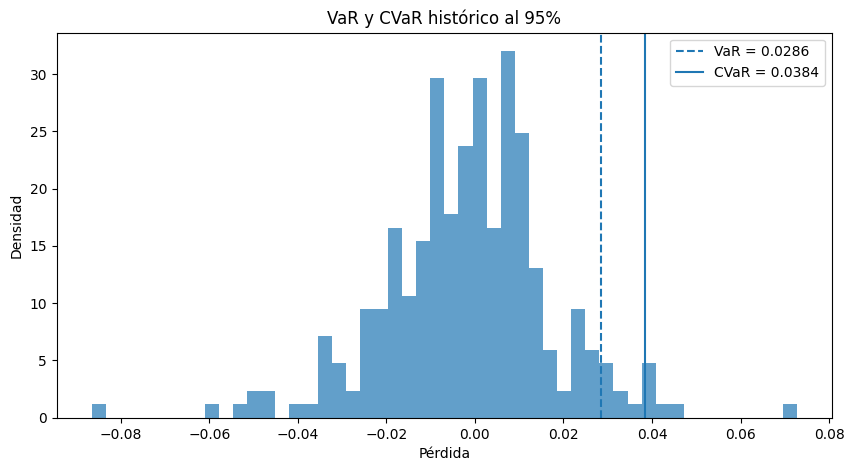

In [84]:
var_h, cvar_h = var_cvar_historico(perdidas, confianza=0.95)

graficar_var_cvar(
    perdidas,
    var_h,
    cvar_h,
    titulo="VaR y CVaR histórico al 95%"
)